<a href="https://colab.research.google.com/github/smitp2705/data_prepro_practicle_test/blob/main/Data_Prepro_PR_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import json

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import zscore
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load CSV
riders = pd.read_csv("/content/riders - riders.csv (1).csv")

# Load JSON
trips = pd.read_json("/content/trips (1).json")

# Load SQL
conn = sqlite3.connect(":memory:")

with open("/content/city_zones (2).sql", "r") as f:
    sql_script = f.read()

conn.executescript(sql_script)

city_zones = pd.read_sql("SELECT * FROM city_zones;", conn)

In [4]:
print("Riders Dataset")
display(riders.head())

print("Trips Dataset")
display(trips.head())

print("City Zones Dataset")
display(city_zones.head())

Riders Dataset


,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating
0,R0001,Aarav Das,23,Male,Pune,2020-06-29,56,0,3.76
1,R0002,Ishaan Nair,39,Female,Mumbai,2019-11-23,70,5,4.12
2,R0003,Kavya Reddy,34,Male,Pune,2023-05-04,45,9,3.76
3,R0004,Aarav Nair,19,Other,Kolkata,2019-07-28,464,5,3.19
4,R0005,Diya Reddy,27,Male,Ahmedabad,2021-05-31,294,30,3.53


Trips Dataset


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,1
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,1


City Zones Dataset


,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type
0,Zone_1,4921,2.43,30.9,Residential
1,Zone_2,6371,0.91,58.4,Residential
2,Zone_3,12971,2.11,38.0,Business
3,Zone_4,4038,2.46,48.2,Business
4,Zone_5,2590,1.31,43.9,Business


In [ ]:
print("Riders Info")
riders.info()

print("\nTrips Info")
trips.info()

print("\nCity Zones Info")
city_zones.info()

Riders Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rider_id         300 non-null    object 
 1   name             300 non-null    object 
 2   age              300 non-null    int64  
 3   gender           300 non-null    object 
 4   city             300 non-null    object 
 5   signup_date      300 non-null    object 
 6   total_rides      300 non-null    int64  
 7   cancelled_rides  300 non-null    int64  
 8   avg_rating       300 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 21.2+ KB

Trips Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trip_id       2000 non-null   object 
 1   rider_id      2000 non-null   object 
 2   zone          2000 n

In [ ]:
print("Riders Missing Values")
print(riders.isnull().sum())

Riders Missing Values
rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64


In [ ]:
print("\nTrips Missing Values")
print(trips.isnull().sum())


Trips Missing Values
trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64


In [ ]:
print("\nCity Zones Missing Values")
print(city_zones.isnull().sum())


City Zones Missing Values
zone_name             0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64


In [ ]:
print(riders.dtypes)

print(trips.dtypes)

print(city_zones.dtypes)

rider_id            object
name                object
age                  int64
gender              object
city                object
signup_date         object
total_rides          int64
cancelled_rides      int64
avg_rating         float64
dtype: object
trip_id          object
rider_id         object
zone             object
distance_km     float64
duration_min    float64
fare_amount     float64
payment_mode     object
ride_date        object
surge_flag        int64
dtype: object
zone_name              object
population_density      int64
traffic_index         float64
avg_speed_kmph        float64
zone_type              object
dtype: object


In [ ]:
print("Riders Duplicate :", riders.duplicated().sum())

print("Trips Duplicate :", trips.duplicated().sum())

print("City Zones Duplicate :", city_zones.duplicated().sum())

Riders Duplicate : 0
Trips Duplicate : 0
City Zones Duplicate : 0


In [ ]:
riders.describe()

,age,total_rides,cancelled_rides,avg_rating
count,300.000000,300.000000,300.000000,300.000000
mean,31.466667,244.690000,22.983333,3.991000
std,7.863098,146.406843,21.455633,0.559643
min,18.000000,4.000000,0.000000,3.000000
25%,26.000000,112.750000,7.000000,3.547500
50%,31.000000,241.000000,16.000000,3.925000
75%,37.000000,366.750000,32.000000,4.480000
max,55.000000,499.000000,94.000000,5.000000


In [ ]:
trips.describe()

,distance_km,duration_min,fare_amount,surge_flag
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.247420,61.883410,134.600375,0.510500
std,4.450904,35.980603,85.521989,0.500015
min,0.020000,0.190000,0.250000,0.000000
25%,4.887500,35.415000,70.440000,0.000000
50%,8.115000,58.950000,121.850000,1.000000
75%,11.362500,85.375000,182.867500,1.000000
max,25.860000,201.070000,472.290000,1.000000


In [ ]:
city_zones.describe()

,population_density,traffic_index,avg_speed_kmph
count,10.000000,10.000000,10.000000
mean,7458.100000,1.570000,42.470000
std,4527.581706,0.703199,9.666557
min,2440.000000,0.540000,30.900000
25%,4157.500000,1.010000,35.950000
50%,5646.000000,1.685000,40.950000
75%,11061.750000,2.065000,47.450000
max,14627.000000,2.460000,58.400000


In [ ]:
# Numerical columns
riders_num = riders.select_dtypes(include=np.number).columns
trips_num = trips.select_dtypes(include=np.number).columns
city_zones_num = city_zones.select_dtypes(include=np.number).columns

# Categorical columns
riders_cat = riders.select_dtypes(include='object').columns
trips_cat = trips.select_dtypes(include='object').columns
city_zones_cat = city_zones.select_dtypes(include='object').columns

In [ ]:
num_imputer = SimpleImputer(strategy="mean")

riders[riders_num] = num_imputer.fit_transform(riders[riders_num])

trips[trips_num] = num_imputer.fit_transform(trips[trips_num])

city_zones[city_zones_num] = num_imputer.fit_transform(city_zones[city_zones_num])

In [ ]:
cat_imputer = SimpleImputer(strategy="most_frequent")

riders[riders_cat] = cat_imputer.fit_transform(riders[riders_cat])

trips[trips_cat] = cat_imputer.fit_transform(trips[trips_cat])

city_zones[city_zones_cat] = cat_imputer.fit_transform(city_zones[city_zones_cat])

In [ ]:
knn = KNNImputer(n_neighbors=5)

riders[riders_num] = knn.fit_transform(riders[riders_num])

trips[trips_num] = knn.fit_transform(trips[trips_num])

city_zones[city_zones_num] = knn.fit_transform(city_zones[city_zones_num])

In [ ]:
riders.drop_duplicates(inplace=True)

trips.drop_duplicates(inplace=True)

city_zones.drop_duplicates(inplace=True)

In [ ]:
trips["fare_amount"] = trips["fare_amount"].abs()

In [ ]:
print(riders.isnull().sum())

print(trips.isnull().sum())

print(city_zones.isnull().sum())

rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64
trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64
zone_name             0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64


In [ ]:
Q1 = trips["fare_amount"].quantile(0.25)
Q3 = trips["fare_amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = trips[
    (trips["fare_amount"] < lower) |
    (trips["fare_amount"] > upper)
]

print("Number of Outliers (IQR):", len(iqr_outliers))

Number of Outliers (IQR): 37


In [ ]:
trips_iqr = trips[
    (trips["fare_amount"] >= lower) &
    (trips["fare_amount"] <= upper)
]

print("Shape Before :", trips.shape)
print("Shape After  :", trips_iqr.shape)

Shape Before : (2000, 9)
Shape After  : (1963, 9)


In [ ]:
print("Original Records :", len(trips))
print("After IQR :", len(trips_iqr))

Original Records : 2000
After IQR : 1963


In [ ]:
trips["fare_amount_winsor"] = winsorize(
    trips["fare_amount"],
    limits=[0.05, 0.05]
)

In [ ]:
print("Original Fare Amount")

print(trips["fare_amount"].describe())

print("\nWinsorized Fare Amount")

print(trips["fare_amount_winsor"].describe())

Original Fare Amount
count    2000.000000
mean      134.600375
std        85.521989
min         0.250000
25%        70.440000
50%       121.850000
75%       182.867500
max       472.290000
Name: fare_amount, dtype: float64

Winsorized Fare Amount
count    2000.000000
mean      132.731120
std        78.900429
min        17.390000
25%        70.440000
50%       121.850000
75%       182.867500
max       297.220000
Name: fare_amount_winsor, dtype: float64


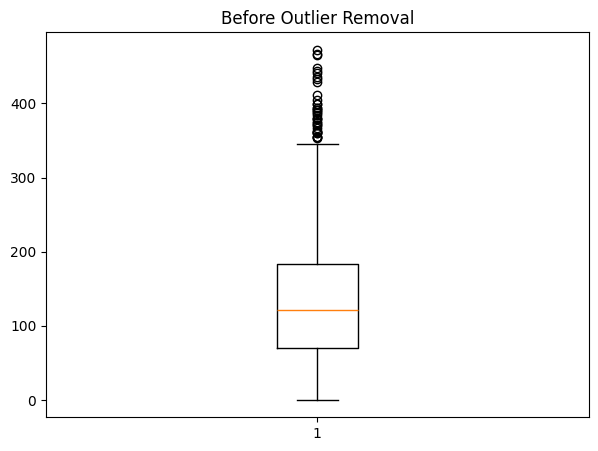

In [ ]:
plt.figure(figsize=(7,5))

plt.boxplot(trips["fare_amount"])

plt.title("Before Outlier Removal")

plt.show()

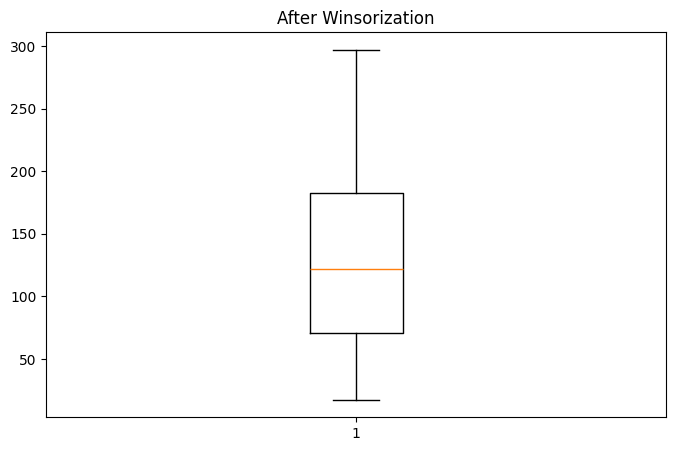

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(trips["fare_amount_winsor"])

plt.title("After Winsorization")

plt.show()

In [ ]:
trips["ride_date"] = pd.to_datetime(trips["ride_date"])
trips["day"] = trips["ride_date"].dt.day
trips["month"] = trips["ride_date"].dt.month
trips["year"] = trips["ride_date"].dt.year

trips.head()

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,ride_date,surge_flag,fare_amount_winsor,day,month,year,payment_mode_Credit Card,payment_mode_UPI,payment_mode_Wallet,Fare_Group,fare_amount_log,fare_amount_sqrt,YearMonth
0,T00001,R0037,Zone_10,11.83,74.59,104.88,2023-11-13,0.0,104.88,13,11,2023,False,False,False,High,4.662306,10.241094,2023-11
1,T00002,R0104,Zone_9,3.86,35.59,40.48,2023-07-28,1.0,40.48,28,7,2023,False,False,False,Low,3.725211,6.362389,2023-07
2,T00003,R0045,Zone_8,4.70,31.03,46.39,2024-01-14,1.0,46.39,14,1,2024,False,False,False,Low,3.858411,6.811020,2024-01
3,T00004,R0089,Zone_2,11.06,59.48,257.64,2023-12-13,0.0,257.64,13,12,2023,False,False,False,High,5.555437,16.051168,2023-12
4,T00005,R0003,Zone_5,7.28,67.59,72.74,2023-03-15,1.0,72.74,15,3,2023,False,True,False,Medium,4.300545,8.528775,2023-03


In [ ]:
le = LabelEncoder()

# Replace "payment_method" with your binary column name
if "payment_method" in trips.columns:
    trips["payment_method"] = le.fit_transform(trips["payment_method"])

# Replace "is_shared" with your binary column if available
if "is_shared" in trips.columns:
    trips["is_shared"] = le.fit_transform(trips["is_shared"])

In [ ]:
trips = pd.get_dummies(
    trips,
    columns=["payment_mode"],
    drop_first=True
)

trips.head()

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,ride_date,surge_flag,fare_amount_winsor,day,month,year,payment_mode_Credit Card,payment_mode_UPI,payment_mode_Wallet
0,T00001,R0037,Zone_10,11.83,74.59,104.88,2023-11-13,0.0,104.88,13,11,2023,False,False,False
1,T00002,R0104,Zone_9,3.86,35.59,40.48,2023-07-28,1.0,40.48,28,7,2023,False,False,False
2,T00003,R0045,Zone_8,4.70,31.03,46.39,2024-01-14,1.0,46.39,14,1,2024,False,False,False
3,T00004,R0089,Zone_2,11.06,59.48,257.64,2023-12-13,0.0,257.64,13,12,2023,False,False,False
4,T00005,R0003,Zone_5,7.28,67.59,72.74,2023-03-15,1.0,72.74,15,3,2023,False,True,False


In [ ]:
if "ride_category" in trips.columns:

    order = [["Economy", "Premium", "Luxury"]]

    oe = OrdinalEncoder(categories=order)

    trips["ride_category"] = oe.fit_transform(
        trips[["ride_category"]]
    )

In [ ]:
trips["Fare_Group"] = pd.cut(
    trips["fare_amount"],
    bins=[0, 50, 100, trips["fare_amount"].max()],
    labels=["Low", "Medium", "High"]
)

trips.head()

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,ride_date,surge_flag,fare_amount_winsor,day,month,year,payment_mode_Credit Card,payment_mode_UPI,payment_mode_Wallet,Fare_Group
0,T00001,R0037,Zone_10,11.83,74.59,104.88,2023-11-13,0.0,104.88,13,11,2023,False,False,False,High
1,T00002,R0104,Zone_9,3.86,35.59,40.48,2023-07-28,1.0,40.48,28,7,2023,False,False,False,Low
2,T00003,R0045,Zone_8,4.70,31.03,46.39,2024-01-14,1.0,46.39,14,1,2024,False,False,False,Low
3,T00004,R0089,Zone_2,11.06,59.48,257.64,2023-12-13,0.0,257.64,13,12,2023,False,False,False,High
4,T00005,R0003,Zone_5,7.28,67.59,72.74,2023-03-15,1.0,72.74,15,3,2023,False,True,False,Medium


In [ ]:
trips["Fare_Group"].value_counts()

,count
Fare_Group,
High,1222
Medium,444
Low,334


In [ ]:
trips["fare_amount_log"] = np.log1p(trips["fare_amount"])

trips[["fare_amount", "fare_amount_log"]].head()

,fare_amount,fare_amount_log
0,104.88,4.662306
1,40.48,3.725211
2,46.39,3.858411
3,257.64,5.555437
4,72.74,4.300545


In [ ]:
trips["fare_amount_sqrt"] = np.sqrt(trips["fare_amount"])

trips[["fare_amount", "fare_amount_sqrt"]].head()

,fare_amount,fare_amount_sqrt
0,104.88,10.241094
1,40.48,6.362389
2,46.39,6.811020
3,257.64,16.051168
4,72.74,8.528775


In [ ]:
trips[
    [
        "fare_amount",
        "fare_amount_log",
        "fare_amount_sqrt"
    ]
].describe()

,fare_amount,fare_amount_log,fare_amount_sqrt
count,2000.000000,2000.000000,2000.000000
mean,134.600375,4.628943,10.926380
std,85.521989,0.894501,3.901565
min,0.250000,0.223144,0.500000
25%,70.440000,4.268857,8.392853
50%,121.850000,4.810963,11.038567
75%,182.867500,5.214215,13.522851
max,472.290000,6.159708,21.732234


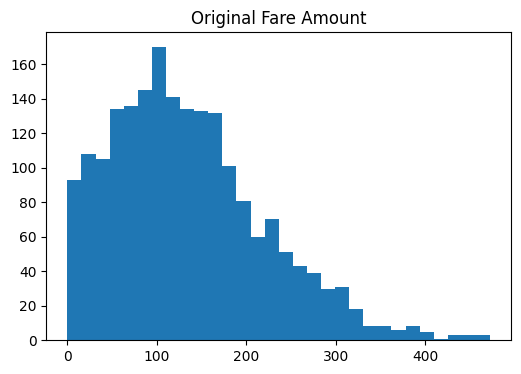

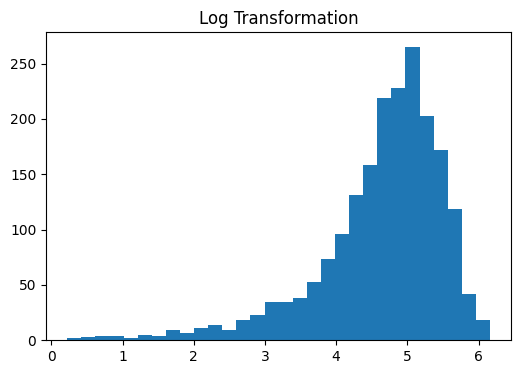

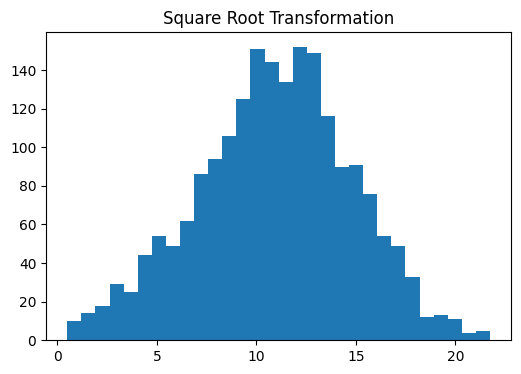

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(trips["fare_amount"], bins=30)
plt.title("Original Fare Amount")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(trips["fare_amount_log"], bins=30)
plt.title("Log Transformation")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(trips["fare_amount_sqrt"], bins=30)
plt.title("Square Root Transformation")
plt.show()

In [ ]:
# Select only numerical columns from trips dataset
num_cols = trips.select_dtypes(include=np.number).columns

print(num_cols)

Index(['distance_km', 'duration_min', 'fare_amount', 'surge_flag',
       'fare_amount_winsor', 'day', 'month', 'year', 'fare_amount_log',
       'fare_amount_sqrt'],
      dtype='object')


In [ ]:
standard_scaler = StandardScaler()

trips_standard = trips.copy()

trips_standard[num_cols] = standard_scaler.fit_transform(
    trips_standard[num_cols]
)

trips_standard.head()

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,ride_date,surge_flag,fare_amount_winsor,day,month,year,payment_mode_Credit Card,payment_mode_UPI,payment_mode_Wallet,Fare_Group,fare_amount_log,fare_amount_sqrt
0,T00001,R0037,Zone_10,0.805112,0.353239,-0.347604,2023-11-13,-1.021225,-0.353079,-0.254043,1.621425,-0.803798,False,False,False,High,0.037307,-0.175688
1,T00002,R0104,Zone_9,-0.985983,-0.730949,-1.100815,2023-07-28,0.979216,-1.169502,1.496370,0.381804,-0.803798,False,False,False,Low,-1.010573,-1.170077
2,T00003,R0045,Zone_8,-0.797210,-0.857716,-1.031693,2024-01-14,0.979216,-1.094579,-0.137349,-1.477629,1.244094,False,False,False,Low,-0.861626,-1.055061
3,T00004,R0089,Zone_2,0.632070,-0.066814,1.439050,2023-12-13,-1.021225,1.583516,-0.254043,1.931331,-0.803798,False,False,False,High,1.036026,1.313850
4,T00005,R0003,Zone_5,-0.217408,0.158642,-0.723508,2023-03-15,0.979216,-0.760530,-0.020655,-0.857818,-0.803798,False,True,False,Medium,-0.367222,-0.614678


In [ ]:
minmax_scaler = MinMaxScaler()

trips_minmax = trips.copy()

trips_minmax[num_cols] = minmax_scaler.fit_transform(
    trips_minmax[num_cols]
)

trips_minmax.head()

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,ride_date,surge_flag,fare_amount_winsor,day,month,year,payment_mode_Credit Card,payment_mode_UPI,payment_mode_Wallet,Fare_Group,fare_amount_log,fare_amount_sqrt
0,T00001,R0037,Zone_10,0.457043,0.370370,0.221655,2023-11-13,0.0,0.312654,0.400000,0.909091,0.0,False,False,False,High,0.747766,0.458788
1,T00002,R0104,Zone_9,0.148607,0.176225,0.085226,2023-07-28,1.0,0.082514,0.900000,0.545455,0.0,False,False,False,Low,0.589915,0.276108
2,T00003,R0045,Zone_8,0.181115,0.153524,0.097746,2024-01-14,1.0,0.103634,0.433333,0.000000,1.0,False,False,False,Low,0.612352,0.297238
3,T00004,R0089,Zone_2,0.427245,0.295151,0.545272,2023-12-13,0.0,0.858557,0.400000,1.000000,0.0,False,False,False,High,0.898212,0.732432
4,T00005,R0003,Zone_5,0.280960,0.335524,0.153567,2023-03-15,1.0,0.197799,0.466667,0.181818,0.0,False,True,False,Medium,0.686828,0.378141


In [ ]:
print("Original Dataset")

display(trips[num_cols].describe())

print("Standard Scaled Dataset")

display(trips_standard[num_cols].describe())

Original Dataset


,distance_km,duration_min,fare_amount,surge_flag,fare_amount_winsor,day,month,year,fare_amount_log,fare_amount_sqrt
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.247420,61.883410,134.600375,0.510500,132.731120,15.177000,5.768000,2023.392500,4.628943,10.926380
std,4.450904,35.980603,85.521989,0.500015,78.900429,8.571546,3.227597,0.488429,0.894501,3.901565
min,0.020000,0.190000,0.250000,0.000000,17.390000,1.000000,1.000000,2023.000000,0.223144,0.500000
25%,4.887500,35.415000,70.440000,0.000000,70.440000,8.000000,3.000000,2023.000000,4.268857,8.392853
50%,8.115000,58.950000,121.850000,1.000000,121.850000,15.000000,6.000000,2023.000000,4.810963,11.038567
75%,11.362500,85.375000,182.867500,1.000000,182.867500,22.000000,8.000000,2024.000000,5.214215,13.522851
max,25.860000,201.070000,472.290000,1.000000,297.220000,31.000000,12.000000,2024.000000,6.159708,21.732234


Standard Scaled Dataset


,distance_km,duration_min,fare_amount,surge_flag,fare_amount_winsor,day,month,year,fare_amount_log,fare_amount_sqrt
count,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03
mean,5.329071e-18,-1.172396e-16,-1.616485e-16,5.861978e-17,-1.243450e-17,4.796163e-17,5.329071e-17,1.490683e-13,4.058975e-16,1.243450e-16
std,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00
min,-1.848945e+00,-1.715058e+00,-1.571338e+00,-1.021225e+00,-1.462222e+00,-1.654374e+00,-1.477629e+00,-8.037976e-01,-4.926661e+00,-2.673027e+00
25%,-7.550736e-01,-7.358139e-01,-7.504084e-01,-1.021225e+00,-7.896877e-01,-8.375146e-01,-8.578184e-01,-8.037976e-01,-4.026561e-01,-6.495242e-01
50%,-2.975870e-02,-8.154793e-02,-1.491261e-01,9.792159e-01,-1.379440e-01,-2.065488e-02,7.189807e-02,-8.037976e-01,2.035390e-01,2.876157e-02
75%,7.000508e-01,6.530592e-01,5.645238e-01,9.792159e-01,6.355975e-01,7.962048e-01,6.917090e-01,1.244094e+00,6.544641e-01,6.656612e-01
max,3.958069e+00,3.869346e+00,3.949558e+00,9.792159e-01,2.085287e+00,1.846453e+00,1.931331e+00,1.244094e+00,1.711735e+00,2.770313e+00


In [ ]:
print("Original Dataset")

display(trips[num_cols].describe())

print("MinMax Scaled Dataset")

display(trips_minmax[num_cols].describe())

Original Dataset


,distance_km,duration_min,fare_amount,surge_flag,fare_amount_winsor,day,month,year,fare_amount_log,fare_amount_sqrt
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.247420,61.883410,134.600375,0.510500,132.731120,15.177000,5.768000,2023.392500,4.628943,10.926380
std,4.450904,35.980603,85.521989,0.500015,78.900429,8.571546,3.227597,0.488429,0.894501,3.901565
min,0.020000,0.190000,0.250000,0.000000,17.390000,1.000000,1.000000,2023.000000,0.223144,0.500000
25%,4.887500,35.415000,70.440000,0.000000,70.440000,8.000000,3.000000,2023.000000,4.268857,8.392853
50%,8.115000,58.950000,121.850000,1.000000,121.850000,15.000000,6.000000,2023.000000,4.810963,11.038567
75%,11.362500,85.375000,182.867500,1.000000,182.867500,22.000000,8.000000,2024.000000,5.214215,13.522851
max,25.860000,201.070000,472.290000,1.000000,297.220000,31.000000,12.000000,2024.000000,6.159708,21.732234


MinMax Scaled Dataset


,distance_km,duration_min,fare_amount,surge_flag,fare_amount_winsor,day,month,year,fare_amount_log,fare_amount_sqrt
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.318399,0.307116,0.284617,0.510500,0.412183,0.472567,0.433455,0.392500,0.742146,0.491064
std,0.172249,0.179115,0.181175,0.500015,0.281958,0.285718,0.293418,0.488429,0.150676,0.183757
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.188371,0.175353,0.148695,0.000000,0.189579,0.233333,0.181818,0.000000,0.681491,0.371739
50%,0.313274,0.292513,0.257605,1.000000,0.373298,0.466667,0.454545,0.000000,0.772807,0.496348
75%,0.438951,0.424059,0.386869,1.000000,0.591350,0.700000,0.636364,1.000000,0.840734,0.613353
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


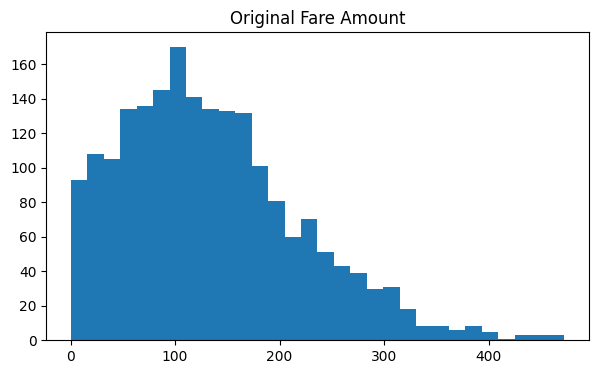

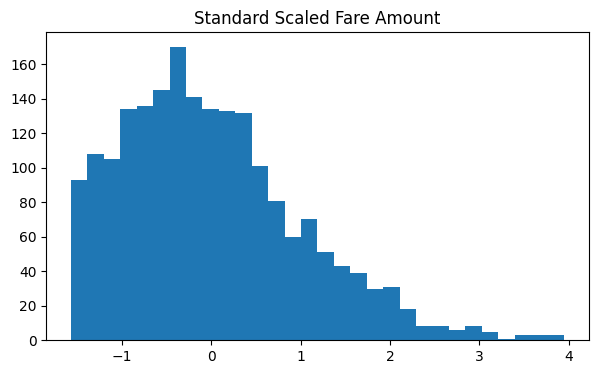

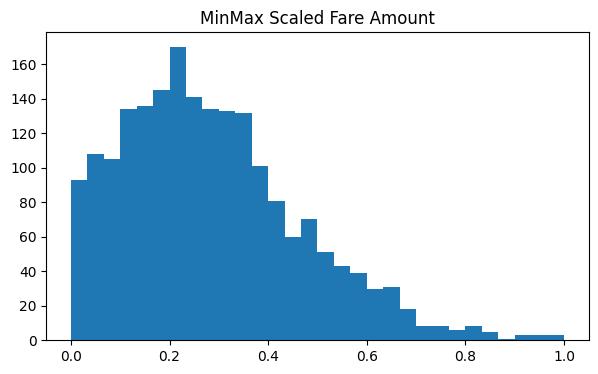

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(trips["fare_amount"], bins=30)
plt.title("Original Fare Amount")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(trips_standard["fare_amount"], bins=30)
plt.title("Standard Scaled Fare Amount")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(trips_minmax["fare_amount"], bins=30)
plt.title("MinMax Scaled Fare Amount")
plt.show()

In [ ]:
# Extract Year-Month
trips["YearMonth"] = trips["ride_date"].dt.to_period("M")

# Monthly fare per rider
monthly_fare = (
    trips.groupby(["rider_id", "YearMonth"])["fare_amount"]
    .sum()
    .reset_index(name="Monthly_Fare")
)

# Average monthly fare
avg_monthly_fare = (
    monthly_fare.groupby("rider_id")["Monthly_Fare"]
    .mean()
    .reset_index(name="Avg_Monthly_Fare")
)

avg_monthly_fare.head()

,rider_id,Avg_Monthly_Fare
0,R0001,158.785000
1,R0002,167.944286
2,R0003,138.815714
3,R0004,113.838333
4,R0005,154.408333


In [ ]:
purchase_frequency = (
    trips.groupby("rider_id")
    .size()
    .reset_index(name="Ride_Frequency")
)

purchase_frequency.head()

,rider_id,Ride_Frequency
0,R0001,2
1,R0002,7
2,R0003,10
3,R0004,6
4,R0005,7


In [ ]:
latest_date = trips["ride_date"].max()

last_ride = (
    trips.groupby("rider_id")["ride_date"]
    .max()
    .reset_index()
)

last_ride["Days_Since_Last_Ride"] = (
    latest_date - last_ride["ride_date"]
).dt.days

last_ride.head()

,rider_id,ride_date,Days_Since_Last_Ride
0,R0001,2024-08-09,14
1,R0002,2024-08-03,20
2,R0003,2024-06-29,55
3,R0004,2024-07-23,31
4,R0005,2024-07-27,27


In [ ]:
trips_city_zones = pd.merge(
    trips,
    city_zones,
    left_on="zone",
    right_on="zone_name",
    how="left"
)

In [ ]:
zone_expenditure = (
    trips_city_zones.groupby("zone_type")["fare_amount"]
    .sum()
    .reset_index(name="Total_Fare")
)

zone_expenditure.head()

,zone_type,Total_Fare
0,Business,103310.42
1,Industrial,53716.13
2,Mixed,54707.56
3,Residential,57466.64


In [ ]:
rider_features = (
    avg_monthly_fare
    .merge(purchase_frequency, on="rider_id", how="left")
    .merge(last_ride[["rider_id", "Days_Since_Last_Ride"]], on="rider_id", how="left")
)

rider_features.head()

,rider_id,Avg_Monthly_Fare,Ride_Frequency,Days_Since_Last_Ride
0,R0001,158.785000,2,14
1,R0002,167.944286,7,20
2,R0003,138.815714,10,55
3,R0004,113.838333,6,31
4,R0005,154.408333,7,27


In [ ]:
final_riders = pd.merge(
    riders,
    rider_features,
    on="rider_id",
    how="left"
)

final_riders.head()

,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating,Avg_Monthly_Fare,Ride_Frequency,Days_Since_Last_Ride
0,R0001,Aarav Das,23.0,Male,Pune,2020-06-29,56.0,0.0,3.76,158.785000,2.0,14.0
1,R0002,Ishaan Nair,39.0,Female,Mumbai,2019-11-23,70.0,5.0,4.12,167.944286,7.0,20.0
2,R0003,Kavya Reddy,34.0,Male,Pune,2023-05-04,45.0,9.0,3.76,138.815714,10.0,55.0
3,R0004,Aarav Nair,19.0,Other,Kolkata,2019-07-28,464.0,5.0,3.19,113.838333,6.0,31.0
4,R0005,Diya Reddy,27.0,Male,Ahmedabad,2021-05-31,294.0,30.0,3.53,154.408333,7.0,27.0


In [ ]:
print("Number of Features :", final_riders.shape[1])

print("Number of Records :", final_riders.shape[0])

final_riders.head()

Number of Features : 12
Number of Records : 300


,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating,Avg_Monthly_Fare,Ride_Frequency,Days_Since_Last_Ride
0,R0001,Aarav Das,23.0,Male,Pune,2020-06-29,56.0,0.0,3.76,158.785000,2.0,14.0
1,R0002,Ishaan Nair,39.0,Female,Mumbai,2019-11-23,70.0,5.0,4.12,167.944286,7.0,20.0
2,R0003,Kavya Reddy,34.0,Male,Pune,2023-05-04,45.0,9.0,3.76,138.815714,10.0,55.0
3,R0004,Aarav Nair,19.0,Other,Kolkata,2019-07-28,464.0,5.0,3.19,113.838333,6.0,31.0
4,R0005,Diya Reddy,27.0,Male,Ahmedabad,2021-05-31,294.0,30.0,3.53,154.408333,7.0,27.0


In [ ]:
print("Number of Features :", final_riders.shape[1])

print("Number of Records :", final_riders.shape[0])

final_riders.head()

Number of Features : 12
Number of Records : 300


,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating,Avg_Monthly_Fare,Ride_Frequency,Days_Since_Last_Ride
0,R0001,Aarav Das,23.0,Male,Pune,2020-06-29,56.0,0.0,3.76,158.785000,2.0,14.0
1,R0002,Ishaan Nair,39.0,Female,Mumbai,2019-11-23,70.0,5.0,4.12,167.944286,7.0,20.0
2,R0003,Kavya Reddy,34.0,Male,Pune,2023-05-04,45.0,9.0,3.76,138.815714,10.0,55.0
3,R0004,Aarav Nair,19.0,Other,Kolkata,2019-07-28,464.0,5.0,3.19,113.838333,6.0,31.0
4,R0005,Diya Reddy,27.0,Male,Ahmedabad,2021-05-31,294.0,30.0,3.53,154.408333,7.0,27.0


In [ ]:
# Merge riders with rider features
final_dataset = pd.merge(
    final_riders,
    trips,
    on="rider_id",
    how="left"
)

# Merge with city zones
final_dataset = pd.merge(
    final_dataset,
    city_zones,
    left_on="zone",
    right_on="zone_name",
    how="left"
)

final_dataset.head()

,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating,Avg_Monthly_Fare,...,payment_mode_Wallet,Fare_Group,fare_amount_log,fare_amount_sqrt,YearMonth,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type
0,R0001,Aarav Das,23.0,Male,Pune,2020-06-29,56.0,0.0,3.76,158.785000,...,False,High,5.530183,15.848975,2024-08,Zone_5,2590.0,1.31,43.9,Business
1,R0001,Aarav Das,23.0,Male,Pune,2020-06-29,56.0,0.0,3.76,158.785000,...,True,Medium,4.210348,8.147392,2023-01,Zone_4,4038.0,2.46,48.2,Business
2,R0002,Ishaan Nair,39.0,Female,Mumbai,2019-11-23,70.0,5.0,4.12,167.944286,...,False,High,4.870837,11.376731,2024-03,Zone_9,11037.0,1.83,56.1,Mixed
3,R0002,Ishaan Nair,39.0,Female,Mumbai,2019-11-23,70.0,5.0,4.12,167.944286,...,False,High,4.984907,12.049481,2023-11,Zone_5,2590.0,1.31,43.9,Business
4,R0002,Ishaan Nair,39.0,Female,Mumbai,2019-11-23,70.0,5.0,4.12,167.944286,...,False,High,5.017942,12.251531,2024-02,Zone_10,2440.0,1.54,35.4,Industrial


In [ ]:
drop_cols = [
    "rider_id",
    "trip_id",
    "pickup_datetime",
    "YearMonth"
]

final_dataset.drop(columns=drop_cols, inplace=True, errors="ignore")

In [ ]:
bool_cols = final_dataset.select_dtypes(include="bool").columns

final_dataset[bool_cols] = final_dataset[bool_cols].astype(int)

In [ ]:
categorical_cols = final_dataset.select_dtypes(include="object").columns

final_dataset = pd.get_dummies(
    final_dataset,
    columns=categorical_cols,
    drop_first=True
)

In [ ]:
scaler = StandardScaler()

num_cols = final_dataset.select_dtypes(include=["int64", "float64"]).columns

final_dataset[num_cols] = scaler.fit_transform(final_dataset[num_cols])

In [ ]:
final_dataset

,age,total_rides,cancelled_rides,avg_rating,Avg_Monthly_Fare,Ride_Frequency,Days_Since_Last_Ride,distance_km,duration_min,fare_amount,...,zone_name_Zone_3,zone_name_Zone_4,zone_name_Zone_5,zone_name_Zone_6,zone_name_Zone_7,zone_name_Zone_8,zone_name_Zone_9,zone_type_Industrial,zone_type_Mixed,zone_type_Residential
0,-1.100087,-1.345044,-1.082009,-0.436698,-0.068064,-2.191805,-0.870140,2.011910,1.957282,1.363612,...,False,False,True,False,False,False,False,False,False,False
1,-1.100087,-1.345044,-1.082009,-0.436698,-0.068064,-2.191805,-0.870140,-1.035424,-0.991710,-0.797893,...,False,True,False,False,False,False,False,False,False,False
2,0.948682,-1.249063,-0.852621,0.213059,0.127337,-0.258996,-0.782923,-0.567986,-0.568321,-0.060472,...,False,False,False,False,False,False,True,False,True,False
3,0.948682,-1.249063,-0.852621,0.213059,0.127337,-0.258996,-0.782923,1.133217,1.584488,0.123854,...,False,False,True,False,False,False,False,False,False,False
4,0.948682,-1.249063,-0.852621,0.213059,0.127337,-0.258996,-0.782923,0.364642,0.456098,0.181281,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,0.820634,0.266067,-0.760866,-0.599137,0.797424,-0.645558,-0.884676,-0.033130,0.190889,0.148533,...,False,False,False,False,False,False,False,False,False,True
1997,0.820634,0.266067,-0.760866,-0.599137,0.797424,-0.645558,-0.884676,-0.332020,-0.672570,-0.327254,...,False,True,False,False,False,False,False,False,False,False
1998,0.820634,0.266067,-0.760866,-0.599137,0.797424,-0.645558,-0.884676,-0.475847,-0.673126,0.140112,...,False,False,False,False,False,False,True,False,True,False
1999,0.820634,0.266067,-0.760866,-0.599137,0.797424,-0.645558,-0.884676,0.852305,1.329287,0.403969,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
bool_cols = final_dataset.select_dtypes(include=["bool", "boolean"]).columns
print(bool_cols)

Index(['name_Aadhya Ghosh', 'name_Aadhya Gupta', 'name_Aadhya Iyer',
       'name_Aadhya Nair', 'name_Aadhya Patel', 'name_Aadhya Reddy',
       'name_Aadhya Sharma', 'name_Aadhya Singh', 'name_Aarav Das',
       'name_Aarav Ghosh',
       ...
       'zone_name_Zone_3', 'zone_name_Zone_4', 'zone_name_Zone_5',
       'zone_name_Zone_6', 'zone_name_Zone_7', 'zone_name_Zone_8',
       'zone_name_Zone_9', 'zone_type_Industrial', 'zone_type_Mixed',
       'zone_type_Residential'],
      dtype='object', length=401)


In [ ]:
bool_cols = final_dataset.select_dtypes(include=["bool", "boolean"]).columns

final_dataset[bool_cols] = final_dataset[bool_cols].astype(int)

In [ ]:
final_dataset

,age,total_rides,cancelled_rides,avg_rating,Avg_Monthly_Fare,Ride_Frequency,Days_Since_Last_Ride,distance_km,duration_min,fare_amount,...,zone_name_Zone_3,zone_name_Zone_4,zone_name_Zone_5,zone_name_Zone_6,zone_name_Zone_7,zone_name_Zone_8,zone_name_Zone_9,zone_type_Industrial,zone_type_Mixed,zone_type_Residential
0,-1.100087,-1.345044,-1.082009,-0.436698,-0.068064,-2.191805,-0.870140,2.011910,1.957282,1.363612,...,0,0,1,0,0,0,0,0,0,0
1,-1.100087,-1.345044,-1.082009,-0.436698,-0.068064,-2.191805,-0.870140,-1.035424,-0.991710,-0.797893,...,0,1,0,0,0,0,0,0,0,0
2,0.948682,-1.249063,-0.852621,0.213059,0.127337,-0.258996,-0.782923,-0.567986,-0.568321,-0.060472,...,0,0,0,0,0,0,1,0,1,0
3,0.948682,-1.249063,-0.852621,0.213059,0.127337,-0.258996,-0.782923,1.133217,1.584488,0.123854,...,0,0,1,0,0,0,0,0,0,0
4,0.948682,-1.249063,-0.852621,0.213059,0.127337,-0.258996,-0.782923,0.364642,0.456098,0.181281,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,0.820634,0.266067,-0.760866,-0.599137,0.797424,-0.645558,-0.884676,-0.033130,0.190889,0.148533,...,0,0,0,0,0,0,0,0,0,1
1997,0.820634,0.266067,-0.760866,-0.599137,0.797424,-0.645558,-0.884676,-0.332020,-0.672570,-0.327254,...,0,1,0,0,0,0,0,0,0,0
1998,0.820634,0.266067,-0.760866,-0.599137,0.797424,-0.645558,-0.884676,-0.475847,-0.673126,0.140112,...,0,0,0,0,0,0,1,0,1,0
1999,0.820634,0.266067,-0.760866,-0.599137,0.797424,-0.645558,-0.884676,0.852305,1.329287,0.403969,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
bool_cols = final_dataset.select_dtypes(include=["bool", "boolean"]).columns
print(bool_cols)

Index([], dtype='object')


In [ ]:
original_features = riders.shape[1]

final_features = final_dataset.shape[1]

print("Original Features :", original_features)

print("Final Features :", final_features)

print("New Features Created :", final_features - original_features)

Original Features : 9
Final Features : 423
New Features Created : 414


In [ ]:
Q1 = trips["fare_amount"].quantile(0.25)
Q3 = trips["fare_amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before_outliers = trips[
    (trips["fare_amount"] < lower) |
    (trips["fare_amount"] > upper)
]

print("Outliers Before :", len(before_outliers))

Outliers Before : 37


In [ ]:
Q1 = trips_iqr["fare_amount"].quantile(0.25)
Q3 = trips_iqr["fare_amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

after_outliers = trips_iqr[
    (trips_iqr["fare_amount"] < lower) |
    (trips_iqr["fare_amount"] > upper)
]

print("Outliers After :", len(after_outliers))

Outliers After : 2


In [ ]:
print("="*50)

print("FINAL REPORT")

print("="*50)

print("Records Before Cleaning :", len(trips))

print("Records After Cleaning :", len(trips_iqr))

print("Features Created :", final_features - original_features)

print("Remaining Missing Values")

print(final_dataset.isnull().sum().sum())

print("Outliers Before :", len(before_outliers))

print("Outliers After :", len(after_outliers))

print("="*50)

FINAL REPORT
Records Before Cleaning : 2000
Records After Cleaning : 1963
Features Created : 414
Remaining Missing Values
18
Outliers Before : 37
Outliers After : 2


In [ ]:
final_dataset.to_csv(
    "final_cleaned_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully
